In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops"

folders = [
    "data/raw",
    "data/processed",
    "models",
    "reports",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


In [ ]:
import pandas as pd

csv_path = f"{BASE_PATH}/data/raw/churn_sintetico.csv"

df = pd.read_csv(csv_path)

df.head()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


revision


In [ ]:
df.shape

(5000, 16)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null   object 
 13  customer_age          5000 non-null   int64  
 14  is_promo              5000 non-null   int64  
 15  churn                

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure_months,5000.0,NaN,NaN,NaN,36.4072,20.839776,1.0,18.0,36.0,55.0,72.0
monthly_charge,5000.0,NaN,NaN,NaN,65.273282,17.963425,15.0,53.06,64.965,77.3625,127.17
total_charges,5000.0,NaN,NaN,NaN,2371.156582,1555.943231,50.0,1100.3575,2162.81,3432.6575,9083.06
support_tickets,5000.0,NaN,NaN,NaN,1.7104,1.304788,0.0,1.0,2.0,2.0,8.0
late_payments,5000.0,NaN,NaN,NaN,0.697,0.84388,0.0,0.0,0.0,1.0,5.0
avg_monthly_usage_gb,5000.0,NaN,NaN,NaN,120.528458,49.745297,5.0,86.505,120.03,154.1,324.4
contract_type,5000,3,mensual,2750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,5000,4,debito,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,5000,4,fibra,2240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_streaming,5000.0,NaN,NaN,NaN,0.668,0.470978,0.0,0.0,1.0,1.0,1.0


Distribución de la variable objetivo churn

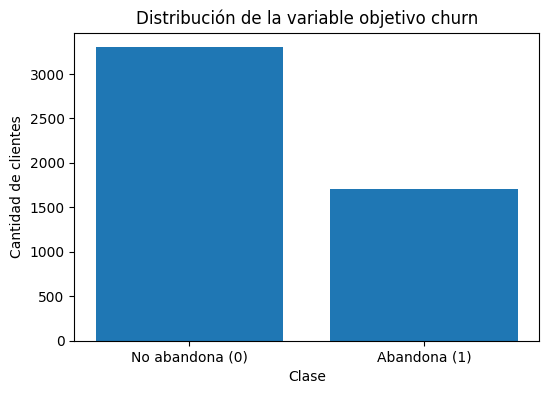

churn
0    3298
1    1702
Name: count, dtype: int64
churn
0    65.96
1    34.04
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

churn_counts = df["churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No abandona (0)", "Abandona (1)"], churn_counts.values)
plt.title("Distribución de la variable objetivo churn")
plt.xlabel("Clase")
plt.ylabel("Cantidad de clientes")
plt.show()

print(churn_counts)
print(df["churn"].value_counts(normalize=True).sort_index() * 100)

La variable objetivo `churn` presenta una mayor proporción de clientes que no abandonan el servicio frente a clientes que sí abandonan. Si bien existe cierto desbalance, la clase positiva mantiene una representación suficiente para entrenar modelos de clasificación binaria. Dado que el objetivo de negocio es detectar clientes con riesgo de abandono, se prioriza especialmente el recall de la clase `churn = 1`.

Churn según tipo de contrato

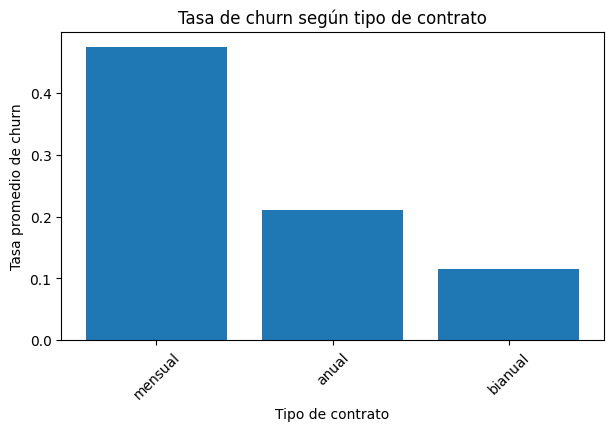

,churn
contract_type,
mensual,0.475273
anual,0.211198
bianual,0.115614


In [ ]:
churn_by_contract = df.groupby("contract_type")["churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.title("Tasa de churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Tasa promedio de churn")
plt.xticks(rotation=45)
plt.show()

churn_by_contract

El análisis de churn por tipo de contrato permite identificar si ciertos esquemas de contratación se asocian con mayor probabilidad de abandono. Esta variable es relevante para el negocio porque puede orientar campañas de retención diferenciadas según el tipo de vínculo comercial del cliente.

Churn según pagos atrasados

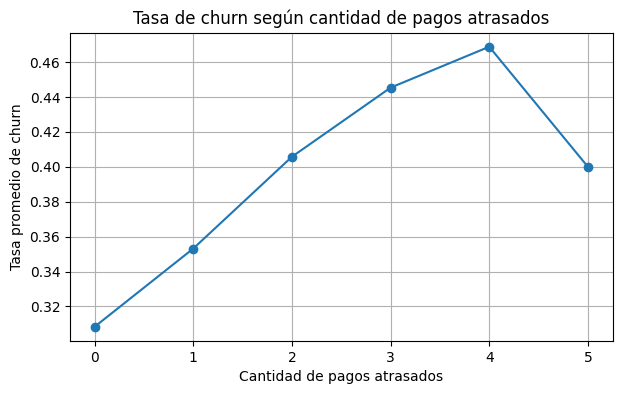

,churn
late_payments,
0,0.308396
1,0.353184
2,0.405751
3,0.445312
4,0.468750
5,0.400000


In [ ]:
churn_by_late_payments = df.groupby("late_payments")["churn"].mean()

plt.figure(figsize=(7, 4))
plt.plot(churn_by_late_payments.index, churn_by_late_payments.values, marker="o")
plt.title("Tasa de churn según cantidad de pagos atrasados")
plt.xlabel("Cantidad de pagos atrasados")
plt.ylabel("Tasa promedio de churn")
plt.grid(True)
plt.show()

churn_by_late_payments

La relación entre pagos atrasados y churn permite observar si los clientes con mayor cantidad de incumplimientos presentan una tasa más alta de abandono. Esta variable puede aportar información útil para anticipar comportamientos de riesgo.

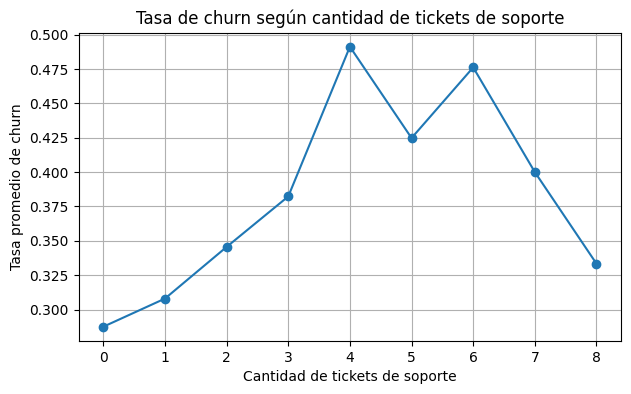

,churn
support_tickets,
0,0.287472
1,0.307943
2,0.345534
3,0.382275
4,0.491228
5,0.424779
6,0.476190
7,0.400000
8,0.333333


In [ ]:
churn_by_tickets = df.groupby("support_tickets")["churn"].mean()

plt.figure(figsize=(7, 4))
plt.plot(churn_by_tickets.index, churn_by_tickets.values, marker="o")
plt.title("Tasa de churn según cantidad de tickets de soporte")
plt.xlabel("Cantidad de tickets de soporte")
plt.ylabel("Tasa promedio de churn")
plt.grid(True)
plt.show()

churn_by_tickets

El análisis de churn según tickets de soporte permite evaluar si los clientes con más interacciones por problemas o consultas presentan mayor probabilidad de abandono. Esta variable puede ser relevante para detectar señales tempranas de insatisfacción.

Comparar variables numéricas con churn

In [ ]:
numeric_summary_by_churn = df.groupby("churn")[numeric_features].mean().T

numeric_summary_by_churn.columns = ["No abandona (0)", "Abandona (1)"]

numeric_summary_by_churn

,No abandona (0),Abandona (1)
tenure_months,38.949666,31.480611
monthly_charge,64.474372,66.821345
total_charges,2511.154424,2099.879918
support_tickets,1.614918,1.895417
late_payments,0.647968,0.792009
avg_monthly_usage_gb,121.161134,119.302509
has_streaming,0.670710,0.662750
has_security_pack,0.546998,0.525852
num_products,2.538205,2.474148
customer_age,47.845058,47.788484


La comparación de promedios por clase permite observar diferencias generales entre clientes que abandonan y clientes que permanecen. Estas diferencias ayudan a justificar la inclusión de variables numéricas en el entrenamiento del modelo.

Churn según tickets de soporte

In [ ]:
df.isnull().sum()

,0
tenure_months,0
monthly_charge,0
total_charges,0
support_tickets,0
late_payments,0
avg_monthly_usage_gb,0
contract_type,0
payment_method,0
internet_service,0
has_streaming,0


confirmar variable objetivo

In [ ]:
target_col = "churn"

df[target_col].value_counts()

,count
churn,
0,3298
1,1702


In [ ]:
df[target_col].value_counts(normalize=True) * 100

,proportion
churn,
0,65.96
1,34.04


Separar variables numéricas y categóricas

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb', 'has_streaming', 'has_security_pack', 'num_products', 'customer_age', 'is_promo']

Variables categóricas:
['contract_type', 'payment_method', 'internet_service', 'region']


Separar entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (4000, 15)
Tamaño X_test: (1000, 15)
Tamaño y_train: (4000,)
Tamaño y_test: (1000,)


*Uso stratify=y para mantener la misma proporción de clientes que abandonan y no abandonan en train y test.*

Preparar el pipeline de preprocesamiento

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['tenure_months', 'monthly_charge',
                                  'total_charges', 'support_tickets',
                                  'late_payments', 'avg_monthly_usage_gb',
                                  'has_streaming', 'has_security_pack',
                                  'num_products', 'customer_age', 'is_promo']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['contract_type', 'payment_method',
                                  'internet_service', 'region'])])

Crear y entrenar el modelo Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

print("Modelo Logistic Regression entrenado correctamente.")

Modelo Logistic Regression entrenado correctamente.


Evaluar el modelo

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred_logistic = logistic_model.predict(X_test)
y_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_proba_logistic)

print("Métricas Logistic Regression")
print("-----------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_logistic))

Métricas Logistic Regression
-----------------------------
Accuracy: 0.723
Precision: 0.6207
Recall: 0.4765
F1-score: 0.5391
ROC-AUC: 0.7577

Matriz de confusión:
[[561  99]
 [178 162]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       660
           1       0.62      0.48      0.54       340

    accuracy                           0.72      1000
   macro avg       0.69      0.66      0.67      1000
weighted avg       0.71      0.72      0.71      1000



*El modelo Logistic Regression funciona como primera aproximación, pero su recall para la clase churn es bajo. Por eso se comparará contra otro modelo más flexible, como Random Forest.*

Crear y entrenar Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


Evaluar Random Forest

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Métricas Random Forest")
print("-----------------------------")
print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-score:", round(f1_rf, 4))
print("ROC-AUC:", round(roc_auc_rf, 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

Métricas Random Forest
-----------------------------
Accuracy: 0.689
Precision: 0.5367
Recall: 0.6235
F1-score: 0.5769
ROC-AUC: 0.7354

Matriz de confusión:
[[477 183]
 [128 212]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       660
           1       0.54      0.62      0.58       340

    accuracy                           0.69      1000
   macro avg       0.66      0.67      0.67      1000
weighted avg       0.70      0.69      0.69      1000



Entrenar Decision Tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Modelo Decision Tree entrenado correctamente.")

Modelo Decision Tree entrenado correctamente.


Evaluar Decision Tree

In [ ]:
y_pred_dt = decision_tree_model.predict(X_test)
y_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("Métricas Decision Tree")
print("-----------------------------")
print("Accuracy:", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall:", round(recall_dt, 4))
print("F1-score:", round(f1_dt, 4))
print("ROC-AUC:", round(roc_auc_dt, 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt))

Métricas Decision Tree
-----------------------------
Accuracy: 0.647
Precision: 0.4867
Recall: 0.6971
F1-score: 0.5732
ROC-AUC: 0.7046

Matriz de confusión:
[[410 250]
 [103 237]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.62      0.70       660
           1       0.49      0.70      0.57       340

    accuracy                           0.65      1000
   macro avg       0.64      0.66      0.64      1000
weighted avg       0.69      0.65      0.66      1000



informe


*Se entrenó un modelo Decision Tree Classifier como alternativa interpretable para la predicción de churn. El modelo fue configurado con una profundidad máxima de 6 niveles y class_weight="balanced" para compensar la diferencia entre clientes que abandonan y clientes que permanecen.

El modelo obtuvo un accuracy de 0.647, precision de 0.4867, recall de 0.6971, F1-score de 0.5732 y ROC-AUC de 0.7046. El resultado más destacable fue el recall, ya que el modelo logró detectar aproximadamente el 69,71% de los clientes que efectivamente abandonaron el servicio.

La matriz de confusión mostró 237 verdaderos positivos y 103 falsos negativos para la clase churn. Esto indica que el modelo reduce la cantidad de clientes en riesgo no detectados. Sin embargo, también generó 250 falsos positivos, lo que implica que muchos clientes fueron clasificados como posibles abandonos cuando en realidad no lo eran.

En conclusión, Decision Tree presenta una buena capacidad para detectar clientes con riesgo de abandono, pero su bajo nivel de precision y su menor rendimiento general frente a otros modelos limitan su elección como modelo final.*

Entrenar Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

extra_trees_model.fit(X_train, y_train)

print("Modelo Extra Trees entrenado correctamente.")

Modelo Extra Trees entrenado correctamente.


Evaluar Extra Trees

In [ ]:
y_pred_et = extra_trees_model.predict(X_test)
y_proba_et = extra_trees_model.predict_proba(X_test)[:, 1]

accuracy_et = accuracy_score(y_test, y_pred_et)
precision_et = precision_score(y_test, y_pred_et)
recall_et = recall_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et)
roc_auc_et = roc_auc_score(y_test, y_proba_et)

print("Métricas Extra Trees")
print("-----------------------------")
print("Accuracy:", round(accuracy_et, 4))
print("Precision:", round(precision_et, 4))
print("Recall:", round(recall_et, 4))
print("F1-score:", round(f1_et, 4))
print("ROC-AUC:", round(roc_auc_et, 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_et))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_et))

Métricas Extra Trees
-----------------------------
Accuracy: 0.667
Precision: 0.5075
Recall: 0.6971
F1-score: 0.5874
ROC-AUC: 0.7338

Matriz de confusión:
[[430 230]
 [103 237]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72       660
           1       0.51      0.70      0.59       340

    accuracy                           0.67      1000
   macro avg       0.66      0.67      0.65      1000
weighted avg       0.71      0.67      0.68      1000



informe


*Se entrenó un modelo Extra Trees Classifier como alternativa basada en ensambles de árboles de decisión. El modelo fue configurado con 200 estimadores, profundidad máxima de 10 y class_weight="balanced" para mejorar la detección de la clase positiva churn.

El modelo obtuvo un accuracy de 0.667, precision de 0.5075, recall de 0.6971, F1-score de 0.5874 y ROC-AUC de 0.7338. El resultado más relevante fue el recall de 0.6971, ya que permitió detectar aproximadamente el 69,71% de los clientes que efectivamente abandonaron el servicio.

La matriz de confusión mostró 237 verdaderos positivos y 103 falsos negativos para la clase churn. En comparación con Decision Tree, Extra Trees mantuvo la misma capacidad de detección de clientes en riesgo, pero redujo los falsos positivos de 250 a 230. Esto significa que el modelo conserva una buena sensibilidad para detectar abandono, pero con un mejor equilibrio general.

En conclusión, Extra Trees se posiciona como uno de los mejores candidatos para modelo final, ya que combina alto recall, mejor F1-score y mejor ROC-AUC que Decision Tree.*

Comparación general de los 4 modelos

Se entrenaron y evaluaron cuatro modelos supervisados de clasificación binaria para predecir churn de clientes: Logistic Regression, Random Forest, Decision Tree y Extra Trees. Todos los modelos fueron integrados en pipelines que incluyen el preprocesamiento de variables numéricas y categóricas, permitiendo una futura serialización y reutilización en inferencia.

Logistic Regression obtuvo el mejor accuracy, con un valor de 0.723, y el mejor ROC-AUC, con 0.7577. Sin embargo, su recall para la clase positiva fue de 0.4765, lo que indica que detecta menos de la mitad de los clientes que realmente abandonan. Esto representa una limitación importante para un caso de churn, donde el objetivo principal es anticiparse a la baja de clientes.

Random Forest presentó un rendimiento más equilibrado, con accuracy de 0.689, recall de 0.6235, F1-score de 0.5769 y ROC-AUC de 0.7354. Este modelo redujo los falsos negativos respecto de Logistic Regression, pasando de 178 a 128 clientes churn no detectados.

Decision Tree obtuvo un recall de 0.6971, detectando una mayor proporción de clientes que efectivamente abandonan. Sin embargo, presentó baja precision, con un valor de 0.4867, y generó una cantidad elevada de falsos positivos, lo que podría provocar campañas de retención innecesarias sobre clientes que no estaban en riesgo real.

Extra Trees obtuvo también un recall de 0.6971, igualando a Decision Tree en capacidad de detección de churn, pero logró mejores métricas generales: precision de 0.5075, F1-score de 0.5874 y ROC-AUC de 0.7338. Además, redujo los falsos positivos respecto de Decision Tree, pasando de 250 a 230.

En conclusión, se selecciona Extra Trees como modelo final inicial, ya que ofrece el mejor equilibrio entre detección de clientes en riesgo y rendimiento general. Aunque Logistic Regression obtuvo mayor accuracy, Extra Trees resulta más adecuado para el problema de negocio porque maximiza la detección de clientes que podrían abandonar el servicio, permitiendo a la empresa activar acciones de retención de forma anticipada.

Crear tabla comparativa de modelos

In [ ]:
import pandas as pd

metrics_comparison = pd.DataFrame({
    "modelo": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Extra Trees"
    ],
    "accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_dt,
        accuracy_et
    ],
    "precision": [
        precision,
        precision_rf,
        precision_dt,
        precision_et
    ],
    "recall": [
        recall,
        recall_rf,
        recall_dt,
        recall_et
    ],
    "f1_score": [
        f1,
        f1_rf,
        f1_dt,
        f1_et
    ],
    "roc_auc": [
        roc_auc,
        roc_auc_rf,
        roc_auc_dt,
        roc_auc_et
    ]
})

metrics_comparison

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.723,0.620690,0.476471,0.539101,0.757696
1,Random Forest,0.689,0.536709,0.623529,0.576871,0.735406
2,Decision Tree,0.647,0.486653,0.697059,0.573156,0.704612
3,Extra Trees,0.667,0.507495,0.697059,0.587361,0.733801


In [ ]:
metrics_comparison_sorted = metrics_comparison.sort_values(
    by=["recall", "f1_score", "roc_auc"],
    ascending=False
)

metrics_comparison_sorted

,modelo,accuracy,precision,recall,f1_score,roc_auc
3,Extra Trees,0.667,0.507495,0.697059,0.587361,0.733801
2,Decision Tree,0.647,0.486653,0.697059,0.573156,0.704612
1,Random Forest,0.689,0.536709,0.623529,0.576871,0.735406
0,Logistic Regression,0.723,0.620690,0.476471,0.539101,0.757696


Guardar la tabla de métricas

In [ ]:
metrics_path = f"{BASE_PATH}/reports/metricas_modelos.csv"

metrics_comparison_sorted.to_csv(metrics_path, index=False)

print("Métricas guardadas en:", metrics_path)

Métricas guardadas en: /content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/metricas_modelos.csv


Guardar el modelo final


In [ ]:
import joblib
import os

model_path = f"{BASE_PATH}/models/modelo_churn_extra_trees.pkl"

joblib.dump(extra_trees_model, model_path)

print("Modelo guardado correctamente en:")
print(model_path)

Modelo guardado correctamente en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/models/modelo_churn_extra_trees.pkl


In [ ]:
os.listdir(f"{BASE_PATH}/models")

['modelo_churn_extra_trees.pkl']

Probar que el modelo se puede cargar

In [ ]:
loaded_model = joblib.load(model_path)

print("Modelo cargado correctamente.")
print(loaded_model)

Modelo cargado correctamente.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure_months',
                                                   'monthly_charge',
                                                   'total_charges',
                                                   'support_tickets',
                                                   'late_payments',
                                                   'avg_monthly_usage_gb',
                                                   'has_streaming',
                                                   'has_security_pack',
                                                   'num_products',
                                                   'customer_age',
                                                   'is_promo']),
                                                 ('cat',
                                                

Probar una predicción con el modelo cargado

In [ ]:
sample_client = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_client)
probability = loaded_model.predict_proba(sample_client)[:, 1]

print("Cliente de prueba:")
display(sample_client)

print("Predicción:", prediction[0])
print("Probabilidad de churn:", round(probability[0], 4))

Cliente de prueba:


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo
4724,21,62.45,1365.15,1,1,142.87,mensual,credito,movil,1,1,3,norte,52,1


Predicción: 1
Probabilidad de churn: 0.7821


El modelo estima que este cliente tiene una probabilidad aproximada del 78,21% de abandonar el servicio. Por lo tanto, sería recomendable incluirlo en una campaña de retención.

Se serializó el pipeline final correspondiente al modelo Extra Trees Classifier utilizando joblib. El artefacto guardado incluye tanto el preprocesamiento de variables numéricas y categóricas como el modelo entrenado, permitiendo realizar inferencias sin necesidad de reentrenamiento.

Luego se validó la correcta carga del archivo serializado y se realizó una predicción sobre un cliente del conjunto de prueba. El modelo predijo churn = 1, con una probabilidad estimada de abandono de 0.7821. Esto demuestra que el artefacto final puede ser utilizado posteriormente por una API de inferencia.

Guardar columnas de entrada para la futura API

In [ ]:
features_path = f"{BASE_PATH}/models/features_modelo.txt"

with open(features_path, "w") as f:
    for col in X.columns:
        f.write(col + "\n")

print("Columnas del modelo guardadas en:")
print(features_path)

Columnas del modelo guardadas en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/models/features_modelo.txt


Crear un ejemplo JSON de entrada

In [ ]:
import json

sample_input = X_test.iloc[0].to_dict()

sample_input

{'tenure_months': 21,
 'monthly_charge': 62.45,
 'total_charges': 1365.15,
 'support_tickets': 1,
 'late_payments': 1,
 'avg_monthly_usage_gb': 142.87,
 'contract_type': 'mensual',
 'payment_method': 'credito',
 'internet_service': 'movil',
 'has_streaming': 1,
 'has_security_pack': 1,
 'num_products': 3,
 'region': 'norte',
 'customer_age': 52,
 'is_promo': 1}

Guardar ese JSON en la carpeta reports

In [ ]:
request_path = f"{BASE_PATH}/reports/ejemplo_request_api.json"

with open(request_path, "w", encoding="utf-8") as f:
    json.dump(sample_input, f, indent=4, ensure_ascii=False)

print("Ejemplo JSON de request guardado en:")
print(request_path)

Ejemplo JSON de request guardado en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/ejemplo_request_api.json


Crear un ejemplo de respuesta de la API

In [ ]:
prediction_value = int(prediction[0])
probability_value = float(round(probability[0], 4))

if probability_value >= 0.70:
    risk_level = "alto"
    message = "Cliente con alto riesgo de abandono"
elif probability_value >= 0.40:
    risk_level = "medio"
    message = "Cliente con riesgo medio de abandono"
else:
    risk_level = "bajo"
    message = "Cliente con bajo riesgo de abandono"

sample_response = {
    "prediction": prediction_value,
    "probability_churn": probability_value,
    "risk_level": risk_level,
    "message": message
}

sample_response

{'prediction': 1,
 'probability_churn': 0.7821,
 'risk_level': 'alto',
 'message': 'Cliente con alto riesgo de abandono'}

Guardar ejemplo


In [ ]:
response_path = f"{BASE_PATH}/reports/ejemplo_response_api.json"

with open(response_path, "w", encoding="utf-8") as f:
    json.dump(sample_response, f, indent=4, ensure_ascii=False)

print("Ejemplo JSON de response guardado en:")
print(response_path)

Ejemplo JSON de response guardado en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/ejemplo_response_api.json


Verificar archivos generados

In [ ]:
import os

os.listdir(f"{BASE_PATH}/reports")

['metricas_modelos.csv',
 'ejemplo_request_api.json',
 'ejemplo_response_api.json']

informe técnico corto en Markdown

In [ ]:

rows, cols = df.shape

target_counts = df[target_col].value_counts()
target_percentages = df[target_col].value_counts(normalize=True) * 100

no_churn_count = target_counts.get(0, 0)
churn_count = target_counts.get(1, 0)

no_churn_pct = target_percentages.get(0, 0)
churn_pct = target_percentages.get(1, 0)

# Crear tabla markdown manual con las métricas
metrics_table_md = "| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |\n"
metrics_table_md += "|---|---:|---:|---:|---:|---:|\n"

for _, row in metrics_comparison_sorted.iterrows():
    metrics_table_md += (
        f"| {row['modelo']} "
        f"| {row['accuracy']:.4f} "
        f"| {row['precision']:.4f} "
        f"| {row['recall']:.4f} "
        f"| {row['f1_score']:.4f} "
        f"| {row['roc_auc']:.4f} |\n"
    )

informe = f"""
# Informe técnico - Etapa 1: Entrenamiento del modelo de churn

## 1. Contexto del problema

AndesLink Servicios Digitales S.A. es una empresa simulada de suscripción mensual que necesita anticipar el abandono de clientes.
El objetivo del proyecto es construir un modelo de Machine Learning capaz de predecir si un cliente tiene riesgo de abandonar el servicio.

El problema se formula como una tarea de clasificación binaria:

- `0`: el cliente no abandona.
- `1`: el cliente abandona.

Desde el punto de vista del negocio, detectar clientes con riesgo de churn permite activar campañas de retención antes de perderlos.

---

## 2. Descripción del dataset

Se utilizó el archivo `churn_sintetico.csv`.

El dataset contiene:

- Cantidad de registros: {rows}
- Cantidad de columnas: {cols}
- Variable objetivo: `{target_col}`

Distribución de la variable objetivo:

- Clientes que no abandonan: {no_churn_count} ({no_churn_pct:.2f}%)
- Clientes que abandonan: {churn_count} ({churn_pct:.2f}%)

Las variables utilizadas incluyen información relacionada con antigüedad del cliente, facturación, uso mensual del servicio, pagos atrasados, tickets de soporte, tipo de contrato, método de pago, región y servicios contratados.

---

## 3. Preparación de datos

Se separaron las variables predictoras de la variable objetivo.

Las variables numéricas fueron transformadas con `StandardScaler`, mientras que las variables categóricas fueron codificadas mediante `OneHotEncoder`.

Para organizar este flujo se utilizó un `ColumnTransformer`, integrado luego dentro de un `Pipeline` de scikit-learn.

Esto permite guardar en un único artefacto tanto el preprocesamiento como el modelo final, facilitando su uso posterior en una API de inferencia.

---

## 4. Separación train/test

El dataset fue dividido en conjunto de entrenamiento y conjunto de prueba usando `train_test_split`.

Se utilizó `stratify=y` para mantener la proporción de clientes que abandonan y no abandonan en ambos conjuntos.

Esto permite realizar una evaluación más representativa del rendimiento del modelo.

---

## 5. Modelos entrenados

Se entrenaron cuatro modelos supervisados de clasificación binaria:

1. Logistic Regression
2. Random Forest
3. Decision Tree
4. Extra Trees

Todos los modelos fueron integrados en pipelines que incluyen el preprocesamiento y el algoritmo de clasificación.

---

## 6. Comparación de métricas

{metrics_table_md}

---

## 7. Análisis de resultados

Logistic Regression obtuvo el mejor accuracy y el mejor ROC-AUC, pero presentó un recall bajo para la clase positiva churn.
Esto significa que, aunque acierta bien en términos generales, deja sin detectar una cantidad importante de clientes que realmente abandonan.

Random Forest mejoró el recall respecto de Logistic Regression, logrando detectar una mayor proporción de clientes con riesgo de churn.

Decision Tree obtuvo uno de los mejores valores de recall, pero presentó menor precision y mayor cantidad de falsos positivos.

Extra Trees igualó a Decision Tree en recall, pero obtuvo mejor F1-score y mejor ROC-AUC, logrando un equilibrio más sólido entre detección de churn y rendimiento general.

---

## 8. Modelo final seleccionado

Se seleccionó como modelo final inicial el modelo `Extra Trees Classifier`.

La elección se justifica porque obtuvo uno de los mejores valores de recall para la clase positiva, lo cual es relevante para el caso de negocio.
En problemas de churn, es importante detectar la mayor cantidad posible de clientes que pueden abandonar el servicio, ya que esto permite tomar acciones preventivas.

Aunque Logistic Regression obtuvo mayor accuracy, Extra Trees resulta más adecuado para este problema porque prioriza la detección de clientes en riesgo.

---

## 9. Serialización del modelo

El pipeline final fue serializado utilizando `joblib` en formato `.pkl`.

Archivo generado:

`models/modelo_churn_extra_trees.pkl`

Este archivo incluye:

- Preprocesamiento de variables numéricas.
- Codificación de variables categóricas.
- Modelo Extra Trees entrenado.

Luego se validó que el modelo pudiera cargarse correctamente desde disco y realizar una predicción sobre un cliente del conjunto de prueba.

---

## 10. Ejemplo de inferencia

Se probó el modelo cargado con un cliente del conjunto de prueba.

El modelo devolvió:

- Predicción: {prediction_value}
- Probabilidad de churn: {probability_value}

Esto demuestra que el artefacto serializado puede utilizarse para inferencia sin necesidad de reentrenar el modelo.

---

## 11. Archivos generados

Durante esta etapa se generaron los siguientes archivos relevantes:

- `models/modelo_churn_extra_trees.pkl`
- `models/features_modelo.txt`
- `reports/metricas_modelos.csv`
- `reports/ejemplo_request_api.json`
- `reports/ejemplo_response_api.json`

---

## 12. Conclusión

En esta primera etapa se construyó un flujo completo de entrenamiento para un modelo de predicción de churn.
Se realizó análisis inicial del dataset, preparación de datos, entrenamiento de modelos, comparación mediante métricas, selección del modelo final y serialización del pipeline.

El modelo final queda preparado para ser utilizado en la siguiente etapa del proyecto, donde será expuesto mediante una API de inferencia con FastAPI.
"""

report_path = f"{BASE_PATH}/reports/informe_entrenamiento_etapa1.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(informe)

print("Informe técnico generado en:")
print(report_path)

Informe técnico generado en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/informe_entrenamiento_etapa1.md


In [ ]:
os.listdir(f"{BASE_PATH}/reports")

['metricas_modelos.csv',
 'ejemplo_request_api.json',
 'ejemplo_response_api.json',
 'informe_entrenamiento_etapa1.md']

In [ ]:
with open(report_path, "r", encoding="utf-8") as f:
    contenido_informe = f.read()

print(contenido_informe)


# Informe técnico - Etapa 1: Entrenamiento del modelo de churn

## 1. Contexto del problema

AndesLink Servicios Digitales S.A. es una empresa simulada de suscripción mensual que necesita anticipar el abandono de clientes.  
El objetivo del proyecto es construir un modelo de Machine Learning capaz de predecir si un cliente tiene riesgo de abandonar el servicio.

El problema se formula como una tarea de clasificación binaria:

- `0`: el cliente no abandona.
- `1`: el cliente abandona.

Desde el punto de vista del negocio, detectar clientes con riesgo de churn permite activar campañas de retención antes de perderlos.

---

## 2. Descripción del dataset

Se utilizó el archivo `churn_sintetico.csv`.

El dataset contiene:

- Cantidad de registros: 5000
- Cantidad de columnas: 16
- Variable objetivo: `churn`

Distribución de la variable objetivo:

- Clientes que no abandonan: 3298 (65.96%)
- Clientes que abandonan: 1702 (34.04%)

Las variables utilizadas incluyen información relacionada con

MLflow en Colab

In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

Configurar MLflow dentro del proyecto

In [ ]:
import mlflow
import mlflow.sklearn
from pathlib import Path

mlruns_path = Path(f"{BASE_PATH}/mlruns")
mlruns_path.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(mlruns_path.as_uri())
mlflow.set_experiment("churn_prediction_etapa1")

print("MLflow configurado correctamente.")
print("Tracking URI:", mlflow.get_tracking_uri())

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/07 03:31:39 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction_etapa1' does not exist. Creating a new experiment.


MLflow configurado correctamente.
Tracking URI: file:///content/drive/MyDrive/laboratorio%20de%20mineria%20de%20datos/proyecto_churn_mlops/mlruns


Registrar los 4 modelos en MLflow

In [ ]:
modelos_mlflow = [
    {
        "nombre": "Logistic Regression",
        "modelo": logistic_model,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "params": {
            "model_type": "LogisticRegression",
            "max_iter": 1000,
            "random_state": 42
        }
    },
    {
        "nombre": "Random Forest",
        "modelo": random_forest_model,
        "accuracy": accuracy_rf,
        "precision": precision_rf,
        "recall": recall_rf,
        "f1_score": f1_rf,
        "roc_auc": roc_auc_rf,
        "params": {
            "model_type": "RandomForestClassifier",
            "n_estimators": 200,
            "max_depth": 10,
            "class_weight": "balanced",
            "random_state": 42
        }
    },
    {
        "nombre": "Decision Tree",
        "modelo": decision_tree_model,
        "accuracy": accuracy_dt,
        "precision": precision_dt,
        "recall": recall_dt,
        "f1_score": f1_dt,
        "roc_auc": roc_auc_dt,
        "params": {
            "model_type": "DecisionTreeClassifier",
            "max_depth": 6,
            "class_weight": "balanced",
            "random_state": 42
        }
    },
    {
        "nombre": "Extra Trees",
        "modelo": extra_trees_model,
        "accuracy": accuracy_et,
        "precision": precision_et,
        "recall": recall_et,
        "f1_score": f1_et,
        "roc_auc": roc_auc_et,
        "params": {
            "model_type": "ExtraTreesClassifier",
            "n_estimators": 200,
            "max_depth": 10,
            "class_weight": "balanced",
            "random_state": 42
        }
    }
]

for item in modelos_mlflow:
    with mlflow.start_run(run_name=item["nombre"]):
        mlflow.log_params(item["params"])

        mlflow.log_metric("accuracy", item["accuracy"])
        mlflow.log_metric("precision", item["precision"])
        mlflow.log_metric("recall", item["recall"])
        mlflow.log_metric("f1_score", item["f1_score"])
        mlflow.log_metric("roc_auc", item["roc_auc"])

        mlflow.log_param("target", target_col)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("stratify", True)

        print(f"Experimento registrado en MLflow: {item['nombre']}")

Experimento registrado en MLflow: Logistic Regression
Experimento registrado en MLflow: Random Forest
Experimento registrado en MLflow: Decision Tree
Experimento registrado en MLflow: Extra Trees


Registrar el modelo final como artefacto en MLflow

In [ ]:
with mlflow.start_run(run_name="Modelo Final - Extra Trees"):
    mlflow.log_params({
        "model_type": "ExtraTreesClassifier",
        "n_estimators": 200,
        "max_depth": 10,
        "class_weight": "balanced",
        "random_state": 42,
        "target": target_col,
        "selected_model_reason": "Mayor recall para churn y mejor F1-score frente a Decision Tree"
    })

    mlflow.log_metric("accuracy", accuracy_et)
    mlflow.log_metric("precision", precision_et)
    mlflow.log_metric("recall", recall_et)
    mlflow.log_metric("f1_score", f1_et)
    mlflow.log_metric("roc_auc", roc_auc_et)

    mlflow.sklearn.log_model(extra_trees_model, artifact_path="modelo_churn_extra_trees")

    mlflow.log_artifact(f"{BASE_PATH}/reports/metricas_modelos.csv")
    mlflow.log_artifact(f"{BASE_PATH}/reports/ejemplo_request_api.json")
    mlflow.log_artifact(f"{BASE_PATH}/reports/ejemplo_response_api.json")
    mlflow.log_artifact(f"{BASE_PATH}/reports/informe_entrenamiento_etapa1.md")

    print("Modelo final y artefactos registrados en MLflow.")

2026/05/07 03:32:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 03:32:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo final y artefactos registrados en MLflow.


In [ ]:
os.listdir(BASE_PATH)

['entrenamiento_churn_1ipynb.ipynb',
 'data',
 'models',
 'reports',
 'notebooks',
 '.ipynb_checkpoints',
 'mlruns']

Ver los experimentos registrados

In [ ]:


experiment = mlflow.get_experiment_by_name("churn_prediction_etapa1")

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs_df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1_score,metrics.recall,metrics.precision,metrics.accuracy,...,params.model_type,params.n_estimators,params.selected_model_reason,params.test_size,params.stratify,params.max_iter,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.user
0,697e80408b29455583c311db31f8332c,863250246373985774,FINISHED,file:///content/drive/MyDrive/laboratorio%20de...,2026-05-07 03:32:49.037000+00:00,2026-05-07 03:33:13.957000+00:00,0.587361,0.697059,0.507495,0.667,...,ExtraTreesClassifier,200,Mayor recall para churn y mejor F1-score frent...,None,None,None,NOTEBOOK,Modelo Final - Extra Trees,fileId=1J8ntJ6HwuNZUjNCXGwRrBpvhVsfsH_G8,root
1,0e3822ffd31840a48312340eb177e75e,863250246373985774,FINISHED,file:///content/drive/MyDrive/laboratorio%20de...,2026-05-07 03:32:21.814000+00:00,2026-05-07 03:32:22.464000+00:00,0.587361,0.697059,0.507495,0.667,...,ExtraTreesClassifier,200,None,0.2,True,None,NOTEBOOK,Extra Trees,fileId=1J8ntJ6HwuNZUjNCXGwRrBpvhVsfsH_G8,root
2,0b789366d81b48e8a1c58edc7037c667,863250246373985774,FINISHED,file:///content/drive/MyDrive/laboratorio%20de...,2026-05-07 03:32:21.028000+00:00,2026-05-07 03:32:21.788000+00:00,0.573156,0.697059,0.486653,0.647,...,DecisionTreeClassifier,None,None,0.2,True,None,NOTEBOOK,Decision Tree,fileId=1J8ntJ6HwuNZUjNCXGwRrBpvhVsfsH_G8,root
3,8e34661fba1f4bc0994dc280ef13094f,863250246373985774,FINISHED,file:///content/drive/MyDrive/laboratorio%20de...,2026-05-07 03:32:20.330000+00:00,2026-05-07 03:32:21.001000+00:00,0.576871,0.623529,0.536709,0.689,...,RandomForestClassifier,200,None,0.2,True,None,NOTEBOOK,Random Forest,fileId=1J8ntJ6HwuNZUjNCXGwRrBpvhVsfsH_G8,root
4,160b98eb9a7a4803b0dc779c74ee58c3,863250246373985774,FINISHED,file:///content/drive/MyDrive/laboratorio%20de...,2026-05-07 03:32:19.635000+00:00,2026-05-07 03:32:20.286000+00:00,0.539101,0.476471,0.620690,0.723,...,LogisticRegression,None,None,0.2,True,1000,NOTEBOOK,Logistic Regression,fileId=1J8ntJ6HwuNZUjNCXGwRrBpvhVsfsH_G8,root


Mostrar solo las columnas importantes

In [ ]:


mlflow_summary = runs_df[
    [
        "tags.mlflow.runName",
        "params.model_type",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1_score",
        "metrics.roc_auc"
    ]
].sort_values(
    by=["metrics.recall", "metrics.f1_score", "metrics.roc_auc"],
    ascending=False
)

mlflow_summary

,tags.mlflow.runName,params.model_type,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.roc_auc
0,Modelo Final - Extra Trees,ExtraTreesClassifier,0.667,0.507495,0.697059,0.587361,0.733801
1,Extra Trees,ExtraTreesClassifier,0.667,0.507495,0.697059,0.587361,0.733801
2,Decision Tree,DecisionTreeClassifier,0.647,0.486653,0.697059,0.573156,0.704612
3,Random Forest,RandomForestClassifier,0.689,0.536709,0.623529,0.576871,0.735406
4,Logistic Regression,LogisticRegression,0.723,0.620690,0.476471,0.539101,0.757696


Guardar evidencia de MLflow en reports

In [ ]:
mlflow_summary_path = f"{BASE_PATH}/reports/mlflow_experimentos_resumen.csv"

mlflow_summary.to_csv(mlflow_summary_path, index=False)

print("Resumen de experimentos MLflow guardado en:")
print(mlflow_summary_path)

Resumen de experimentos MLflow guardado en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/mlflow_experimentos_resumen.csv


In [ ]:
os.listdir(f"{BASE_PATH}/reports")

['metricas_modelos.csv',
 'ejemplo_request_api.json',
 'ejemplo_response_api.json',
 'informe_entrenamiento_etapa1.md',
 'mlflow_experimentos_resumen.csv']

Instalar DVC

In [ ]:
!pip install dvc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374

Inicializar Git y DVC en el proyecto

In [ ]:
import os
import subprocess

def run_command(command, cwd=BASE_PATH):
    result = subprocess.run(
        command,
        cwd=cwd,
        shell=True,
        capture_output=True,
        text=True
    )
    print("COMANDO:", command)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)

run_command("git init")
run_command("dvc init")

COMANDO: git init
Initialized empty Git repository in /content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/.git/

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>

COMANDO: dvc init
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
| 

Versionar el dataset con DVC

In [ ]:
run_command("dvc add data/raw/churn_sintetico.csv")

COMANDO: dvc add data/raw/churn_sintetico.csv

To track the changes with git, run:

	git add data/raw/.gitignore data/raw/churn_sintetico.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true



Versionar el modelo final con DVC

In [ ]:
run_command("dvc add models/modelo_churn_extra_trees.pkl")

COMANDO: dvc add models/modelo_churn_extra_trees.pkl

To track the changes with git, run:

	git add models/modelo_churn_extra_trees.pkl.dvc models/.gitignore

To enable auto staging, run:

	dvc config core.autostage true



In [ ]:
run_command("find . -name '*.dvc' -o -name '.dvcignore'")

COMANDO: find . -name '*.dvc' -o -name '.dvcignore'
./data/raw/churn_sintetico.csv.dvc
./models/modelo_churn_extra_trees.pkl.dvc
./.dvc
./.dvcignore



Ver estado de Git

In [ ]:
run_command("git status")

COMANDO: git status
On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .dvc/.gitignore
	new file:   .dvc/config
	new file:   .dvcignore

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/
	entrenamiento_churn_1ipynb.ipynb
	mlruns/
	models/
	reports/




Crear evidencia de reproducibilidad

In [ ]:
repro_path = f"{BASE_PATH}/reports/evidencia_reproducibilidad_dvc.txt"

commands = [
    "git status",
    "dvc status",
    "find . -name '*.dvc' -o -name '.dvcignore'"
]

with open(repro_path, "w", encoding="utf-8") as f:
    for command in commands:
        result = subprocess.run(
            command,
            cwd=BASE_PATH,
            shell=True,
            capture_output=True,
            text=True
        )
        f.write(f"\n\n### COMANDO: {command}\n")
        f.write(result.stdout)
        if result.stderr:
            f.write("\nSTDERR:\n")
            f.write(result.stderr)

print("Evidencia de reproducibilidad guardada en:")
print(repro_path)

Evidencia de reproducibilidad guardada en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/reports/evidencia_reproducibilidad_dvc.txt


In [ ]:

os.listdir(f"{BASE_PATH}/reports")

['metricas_modelos.csv',
 'ejemplo_request_api.json',
 'ejemplo_response_api.json',
 'informe_entrenamiento_etapa1.md',
 'mlflow_experimentos_resumen.csv',
 'evidencia_reproducibilidad_dvc.txt']

Crear requirements.txt

In [ ]:
requirements_content = """
pandas
numpy
scikit-learn
matplotlib
joblib
mlflow
dvc
"""

requirements_path = f"{BASE_PATH}/requirements.txt"

with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements_content.strip())

print("Archivo requirements.txt creado en:")
print(requirements_path)

Archivo requirements.txt creado en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/requirements.txt


Crear environment.yml

In [ ]:
environment_content = """
name: churn-mlops
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - pip
  - pip:
      - pandas
      - numpy
      - scikit-learn
      - matplotlib
      - joblib
      - mlflow
      - dvc
"""

environment_path = f"{BASE_PATH}/environment.yml"

with open(environment_path, "w", encoding="utf-8") as f:
    f.write(environment_content.strip())

print("Archivo environment.yml creado en:")
print(environment_path)

 README.md

In [ ]:
readme_content = """
# Proyecto MLOps Local - Predicción de Churn

## 1. Descripción del proyecto

Este proyecto corresponde a la Etapa 1 del trabajo integrador de Laboratorio de Minería de Datos.

El objetivo es construir un modelo de Machine Learning capaz de predecir el abandono de clientes, también conocido como churn, para una empresa simulada llamada AndesLink Servicios Digitales S.A.

El problema se aborda como una clasificación binaria:

- 0: el cliente no abandona.
- 1: el cliente abandona.

## 2. Dataset utilizado

Se utilizó el archivo:

data/raw/churn_sintetico.csv

El dataset contiene información relacionada con:

- Antigüedad del cliente.
- Facturación mensual.
- Cargos totales.
- Tickets de soporte.
- Pagos atrasados.
- Uso mensual del servicio.
- Tipo de contrato.
- Método de pago.
- Servicio de internet.
- Servicios adicionales.
- Región.
- Edad del cliente.
- Promociones.
- Variable objetivo churn.

## 3. Flujo de trabajo de la Etapa 1

Durante esta etapa se realizaron los siguientes pasos:

1. Carga del dataset.
2. Análisis exploratorio inicial.
3. Revisión de valores nulos y tipos de datos.
4. Separación de variables predictoras y variable objetivo.
5. Separación en train/test.
6. Preprocesamiento de variables numéricas y categóricas.
7. Entrenamiento de modelos supervisados.
8. Evaluación con métricas de clasificación.
9. Comparación de modelos.
10. Selección del modelo final.
11. Serialización del pipeline entrenado.
12. Registro de experimentos con MLflow.
13. Evidencia de reproducibilidad con DVC.

## 4. Modelos entrenados

Se entrenaron y compararon los siguientes modelos:

- Logistic Regression
- Random Forest
- Decision Tree
- Extra Trees

El modelo seleccionado como artefacto final fue:

Extra Trees Classifier

La elección se justifica porque obtuvo uno de los mejores valores de recall para la clase positiva churn, empatando con Decision Tree, pero con mejor F1-score y mejor ROC-AUC.

## 5. Archivos principales generados

### Modelo final

models/modelo_churn_extra_trees.pkl

Este archivo contiene el pipeline completo:

- Preprocesamiento de variables numéricas.
- Codificación de variables categóricas.
- Modelo Extra Trees entrenado.

### Columnas esperadas por el modelo

models/features_modelo.txt

### Reportes

reports/metricas_modelos.csv
reports/mlflow_experimentos_resumen.csv
reports/informe_entrenamiento_etapa1.md
reports/ejemplo_request_api.json
reports/ejemplo_response_api.json
reports/evidencia_reproducibilidad_dvc.txt

## 6. Instalación de dependencias

Para instalar las dependencias con pip:

pip install -r requirements.txt

Para crear el entorno con conda:

conda env create -f environment.yml
conda activate churn-mlops

## 7. Ejecución del notebook

El entrenamiento fue desarrollado en Google Colab.

Notebook principal:

entrenamiento_churn_1ipynb.ipynb

El notebook permite reproducir:

- Carga del dataset.
- Entrenamiento de modelos.
- Comparación de métricas.
- Selección del modelo final.
- Serialización del modelo.
- Registro de experimentos con MLflow.
- Evidencia DVC.

## 8. Resultado final

El modelo final quedó guardado como archivo .pkl y fue validado mediante una prueba de carga e inferencia.

Esto permite utilizar el artefacto en la siguiente etapa del proyecto, donde será expuesto mediante una API con FastAPI.
"""

readme_path = f"{BASE_PATH}/README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content.strip())

print("README.md creado correctamente en:")
print(readme_path)

README.md creado correctamente en:
/content/drive/MyDrive/laboratorio de mineria de datos/proyecto_churn_mlops/README.md


In [ ]:
os.listdir(BASE_PATH)

['entrenamiento_churn_1ipynb.ipynb',
 'data',
 'models',
 'reports',
 'notebooks',
 '.ipynb_checkpoints',
 'mlruns',
 '.git',
 '.dvc',
 '.dvcignore',
 'requirements.txt',
 'README.md']

In [ ]:
os.listdir(f"{BASE_PATH}/models")


['modelo_churn_extra_trees.pkl',
 'features_modelo.txt',
 '.gitignore',
 'modelo_churn_extra_trees.pkl.dvc']

In [ ]:
os.listdir(f"{BASE_PATH}/reports")

['metricas_modelos.csv',
 'ejemplo_request_api.json',
 'ejemplo_response_api.json',
 'informe_entrenamiento_etapa1.md',
 'mlflow_experimentos_resumen.csv',
 'evidencia_reproducibilidad_dvc.txt']

Configurar usuario de Git

In [ ]:
!git config --global user.name "Gianmarco Rios"
!git config --global user.email "gianmarco@example.com"

Ver estado actual de Git

In [ ]:
run_command("git status")

COMANDO: git status
On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .dvc/.gitignore
	new file:   .dvc/config
	new file:   .dvcignore

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	README.md
	data/
	entrenamiento_churn_1ipynb.ipynb
	mlruns/
	models/
	reports/
	requirements.txt




Agregar archivos al control de versiones

In [ ]:
run_command("git add README.md requirements.txt environment.yml")
run_command("git add data/raw/churn_sintetico.csv.dvc")
run_command("git add models/modelo_churn_extra_trees.pkl.dvc")
run_command("git add models/features_modelo.txt")
run_command("git add reports/")
run_command("git add .dvc .dvcignore .gitignore")

COMANDO: git add README.md requirements.txt environment.yml

fatal: pathspec 'environment.yml' did not match any files

COMANDO: git add data/raw/churn_sintetico.csv.dvc

COMANDO: git add models/modelo_churn_extra_trees.pkl.dvc

COMANDO: git add models/features_modelo.txt

COMANDO: git add reports/

COMANDO: git add .dvc .dvcignore .gitignore

fatal: pathspec '.gitignore' did not match any files



 commit final

In [ ]:
run_command('git commit -m "Etapa 1 - entrenamiento modelo churn con MLflow y DVC"')

COMANDO: git commit -m "Etapa 1 - entrenamiento modelo churn con MLflow y DVC"
[master (root-commit) 4bff66d] Etapa 1 - entrenamiento modelo churn con MLflow y DVC
 12 files changed, 253 insertions(+)
 create mode 100644 .dvc/.gitignore
 create mode 100644 .dvc/config
 create mode 100644 .dvcignore
 create mode 100644 data/raw/churn_sintetico.csv.dvc
 create mode 100644 models/features_modelo.txt
 create mode 100644 models/modelo_churn_extra_trees.pkl.dvc
 create mode 100644 reports/ejemplo_request_api.json
 create mode 100644 reports/ejemplo_response_api.json
 create mode 100644 reports/evidencia_reproducibilidad_dvc.txt
 create mode 100644 reports/informe_entrenamiento_etapa1.md
 create mode 100644 reports/metricas_modelos.csv
 create mode 100644 reports/mlflow_experimentos_resumen.csv



In [ ]:
run_command("git log --oneline -5")

COMANDO: git log --oneline -5
4bff66d Etapa 1 - entrenamiento modelo churn con MLflow y DVC



In [ ]:
run_command("git status")

COMANDO: git status
On branch master
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	README.md
	data/raw/.gitignore
	entrenamiento_churn_1ipynb.ipynb
	mlruns/
	models/.gitignore
	requirements.txt

nothing added to commit but untracked files present (use "git add" to track)

